From the `Bamboo_setup` directory, run the following command:
```bash
jupyter notebook --no-browser --port=8888
```
Copy the URL starting with `http://localhost:8888/`.
When picking the kernel for this notebook, click **Existing Jupyter Server** and paste the URL.
Name your server 'localhost'.
From localhost, select the 'Python 3' kernel.

In [10]:
import sys
from pathlib import Path
NOTEBOOKS = Path.cwd()                          # <-- Edit as needed
NEURALNET = NOTEBOOKS.parents[0]        # <-- Edit as needed
BAMBOO_SETUP = NOTEBOOKS.parents[2]             # <-- Edit as needed
Z_OUTPUT_eos = Path('/Users/antonett/Documents/HH Analysis/Z_OUTPUT_eos')   # <-- Edit as needed
sys.path.append(str((BAMBOO_SETUP/'src').resolve()))
import pandas as pd
pd.set_option('display.max_columns', None)  # Display all columns
pd.set_option('display.width', 1000)  # Set a larger width to fit the editor window
# pd.set_option('display.max_colwidth', None)  # Allow columns to be fully displayed
%load_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### If any changes are made to the imported modules in this notebook, you must run this cell first to load the new changes (this will reload all modules)

In [14]:
%autoreload 2

# Set up a Data Handler (to load and preprocess all data)

In [16]:
from NeuralNet.DataHandler import DataHandler
datahandler = DataHandler(
    workdir=Z_OUTPUT_eos/'2022_even_0815/Reco',
    tree_name='SL_res_2b_x'
    # total_inputs= NN_POSTPROCESSING / 'input/vars40.txt'
)
total_df = datahandler.load_data()
total_df = datahandler.fix_column_names_mismatch(total_df)
total_df = datahandler.preprocess_data(total_df)
# datahandler.data_quality_summary(total_df)


Loading data...

Preprocessing data ...
	Dropping exact duplicates if any ...
	Removing events with negative weights ...


# Set up your model config

In [17]:
from NeuralNet.utils import ModelConfig
model_config = ModelConfig(
    name='multi_HH_ttbar_tW',
    type='multi',
    categorization={"HH": ["HH_bbWW"], "ttbar": ["ttbar"], "tW": ["tW"]},
    training_weight_sf={"HH_bbWW": 1.0, "ttbar": 8.0, "tW": 4.0},
    input_vars='All',
    architecture_in_yml=True,
    residual_network=False,
    hiddenlayers=[
        {"type": 'Dense', "units": 16, "activation": 'relu', "act_regularizer": {'l2': 1e-4}, "dropout_rate": 0.4}
        # {"type": 'Dense', "units": 16, "activation": 'relu', "act_regularizer": {'l2': 1e-4}, "dropout_rate": 0.4},
        # {"type": 'Dense', "units": 16, "activation": 'relu', "act_regularizer": {'l2': 1e-4}, "dropout_rate": 0.4}
    ],
    outputlayers=[
        {"type": 'Dense', "units": 3, "kernel_initializer": 'normal', "activation": 'softmax', "act_regularizer": {'l2': 1e-4}, "name": 'output'}
    ],
    compiler={"optimizer": 'adam', "lr": 0.001, "loss": 'categorical_crossentropy'},
    fit={"batch_size": 1024, "epochs": 2, "validation_split": 0.25}
)

# Run DNN

Initializing model: multi_HH_ttbar_tW

Preprocessing input ...

Building model ...


Model: "multi_HH_ttbar_tW"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 52)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization (Normalization)   │ (None, 52)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_0 (Dense)                 │ (None, 16)             │           848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 963 (3.76 KB)

 Trainable params: 931 (3.64 KB)

...


Training model ...


Epoch 1/2
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7191 - auc_pr: 0.7302 - auc_roc: 0.8340 - f1_score_macro: 0.3282 - f1_score_micro: 0.7191 - loss: 13.1342 - precision: 0.7825 - precision_HH: 0.0031 - precision_tW: 0.1916 - precision_ttbar: 0.9503 - recall: 0.2916 - recall_HH: 0.0130 - recall_tW: 0.0945 - recall_ttbar: 0.3039 - val_accuracy: 0.9116 - val_auc_pr: 0.9256 - val_auc_roc: 0.9691 - val_f1_score_macro: 0.3978 - val_f1_score_micro: 0.9116 - val_loss: 10.3870 - val_precision: 0.9308 - val_precision_HH: 0.0306 - val_precision_tW: 0.2805 - val_precision_ttbar: 0.9529 - val_recall: 0.8562 - val_recall_HH: 0.0782 - val_recall_tW: 0.1349 - val_recall_ttbar: 0.9008 - learning_rate: 0.0010
Epoch 2/2
704/704 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8938 - auc_pr: 0.9013 - auc_roc: 0.9592 - f1_score_macro: 0.3846 - f1_score_micro: 0.8938 - loss: 10.3698 - precision: 0.9129 - precision_HH: 0.0130 - precision_tW: 0.2138 - precision_ttbar: 0.9524 - recall: 0.8438 - rec


Evaluating model and predicting ...
	Model metrics: {'accuracy': 0.9142046570777893, 'auc_pr': 0.9258837103843689, 'auc_roc': 0.9698507785797119, 'f1_score_macro': 0.3998962938785553, 'f1_score_micro': 0.9142045974731445, 'loss': 0.49351173639297485, 'precision': 0.9291715025901794, 'precision_HH': 0.03258426859974861, 'precision_tW': 0.29801228642463684, 'precision_ttbar': 0.9525189399719238, 'recall': 0.8780421614646912, 'recall_HH': 0.1666666716337204, 'recall_tW': 0.14850692451000214, 'recall_ttbar': 0.9228752255439758}


7503/7503 ━━━━━━━━━━━━━━━━━━━━ 2s 257us/step


({'accuracy': 0.9142046570777893,
  'auc_pr': 0.9258837103843689,
  'auc_roc': 0.9698507785797119,
  'f1_score_macro': 0.3998962938785553,
  'f1_score_micro': 0.9142045974731445,
  'loss': 0.49351173639297485,
  'precision': 0.9291715025901794,
  'precision_HH': 0.03258426859974861,
  'precision_tW': 0.29801228642463684,
  'precision_ttbar': 0.9525189399719238,
  'recall': 0.8780421614646912,
  'recall_HH': 0.1666666716337204,
  'recall_tW': 0.14850692451000214,
  'recall_ttbar': 0.9228752255439758},
 array([[0.24712644, 0.65517241, 0.09770115],
        [0.00973565, 0.95931099, 0.03095336],
        [0.0199563 , 0.800437  , 0.1796067 ]]),
 array([[1.70702660e-02, 4.99824623e-04, 1.79249262e-03],
        [8.74156411e-01, 9.51315328e-01, 7.38190637e-01],
        [1.08773323e-01, 4.81848474e-02, 2.60016871e-01]]),
 ['HH', 'ttbar', 'tW'])

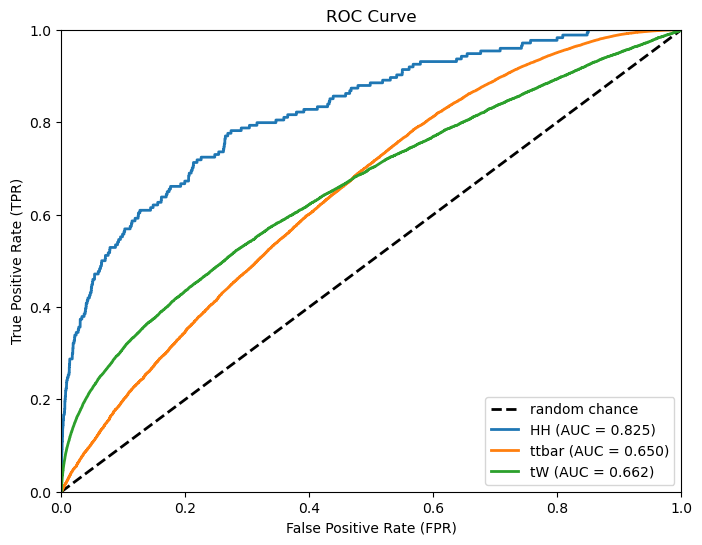

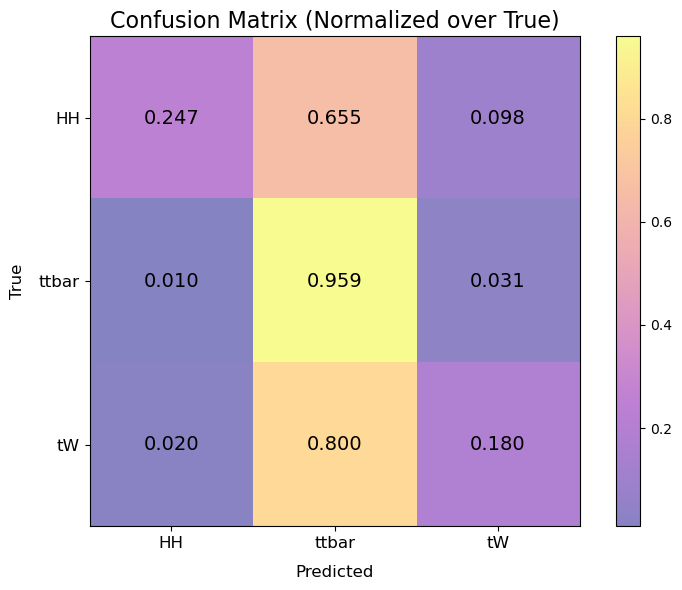

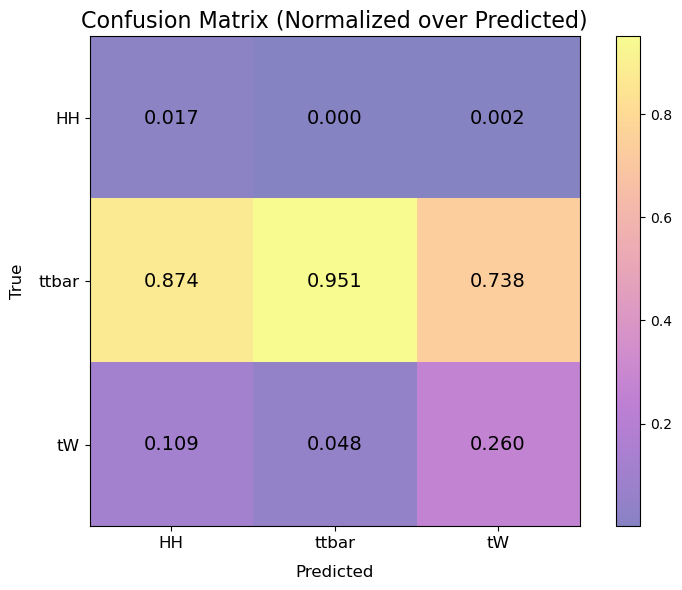

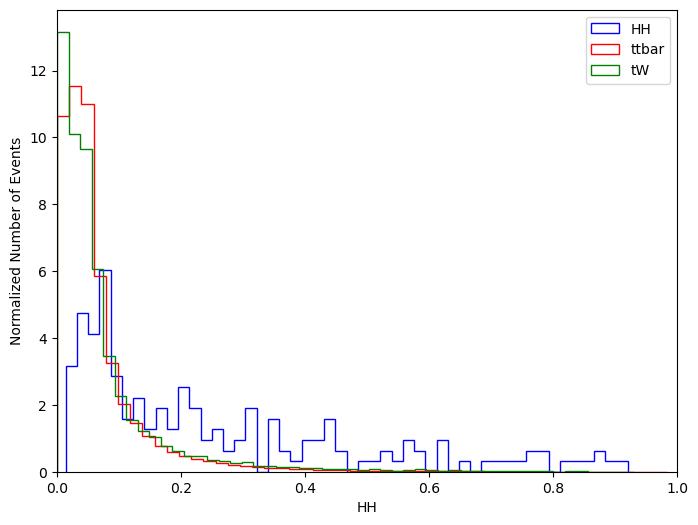

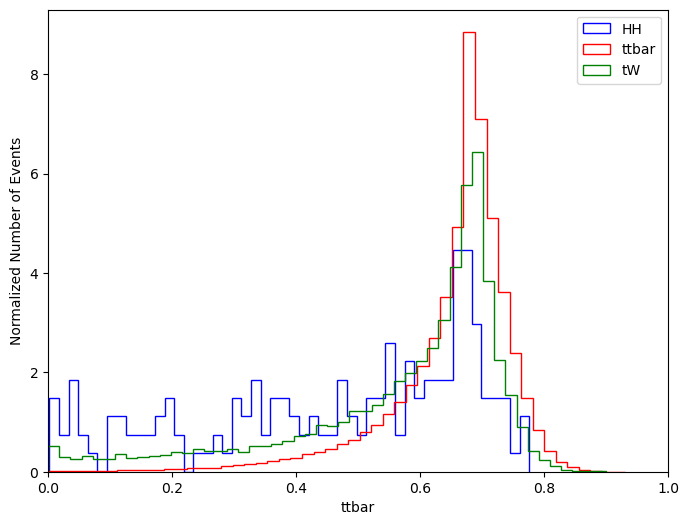

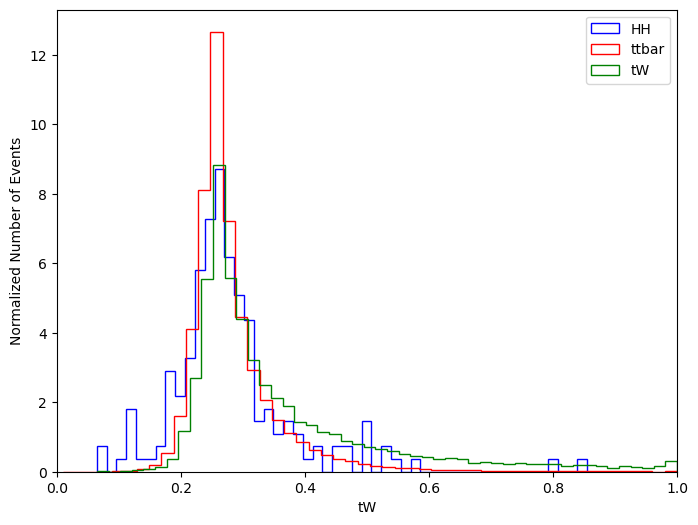

In [19]:
from NeuralNet.DNNModel import DNNModel
DNN = DNNModel(model_config=model_config, modeldir= NOTEBOOKS/'model_custom_trial2')
DNN.Run(total_df, fixed_random_seed=True, save_model_info=False)